In [34]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

In [39]:
folder_single_run = '../outputs/2026-06-22/02-05-59/'

In [40]:
df = pd.read_csv(os.path.join(folder_single_run, 'training_loss.csv'))

<Axes: xlabel='step', ylabel='total_loss'>

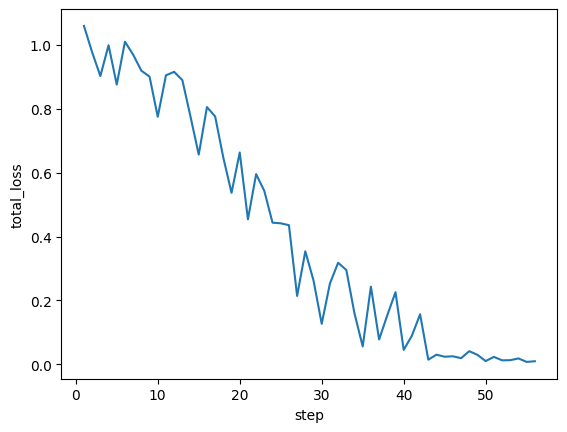

In [41]:
sns.lineplot(x='step', y='total_loss', data=df)

In [45]:
representations = np.load(os.path.join(folder_single_run, 'representations_net1_hidden_0.npy'))

In [46]:
within_sims = []
between_sims = []
for t in range(len(representations)):
    rep_sim = np.corrcoef(representations[t])
    _within_sim = np.array([rep_sim[0,1].item(), rep_sim[2,3].item()]).mean()
    _between_sim = np.array([rep_sim[0,2].item(), rep_sim[0,3].item(), rep_sim[1,2].item(), rep_sim[1,3].item()]).mean()
    within_sims.append(_within_sim)
    between_sims.append(_between_sim)
within_sims = np.array(within_sims)
between_sims = np.array(between_sims)
sim_diff = within_sims - between_sims

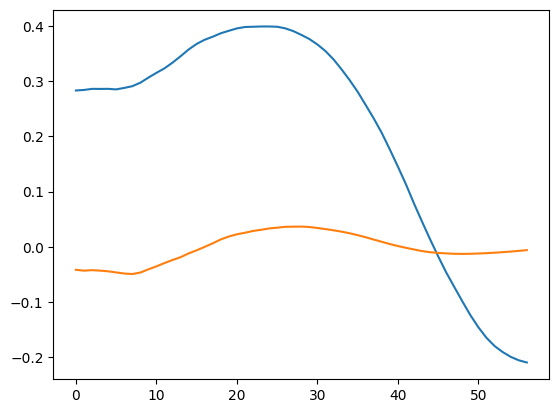

In [47]:
plt.plot(within_sims)
plt.plot(between_sims)

In [7]:
within_sim = representations[:, [(0,1), (2,3)]]

In [9]:
within_sim.shape

(57, 2, 2, 256)

In [52]:
import json

def _compute_sim_diff(representations):
    """Compute within-minus-between similarity trajectory for a (n_steps, 4, dim) array."""
    within_sims = []
    between_sims = []
    for t in range(len(representations)):
        rep_sim = np.corrcoef(representations[t])
        _within  = np.array([rep_sim[0, 1], rep_sim[2, 3]]).mean()
        _between = np.array([rep_sim[0, 2], rep_sim[0, 3],
                             rep_sim[1, 2], rep_sim[1, 3]]).mean()
        within_sims.append(_within)
        between_sims.append(_between)
    return np.array(within_sims) - np.array(between_sims)


def plot_multirun_sim_diff(
    multirun_folder,
    rep_name='representations',
    layer='hidden_0',
    smooth=1,
    shade='sem',
    ax=None,
    title=None,
):
    """
    Plot within-minus-between similarity trajectories for both networks across
    all seeds in a multirun folder.

    Net 0 is labelled 'Dense network' and net 1 'Sparse network'.

    Parameters
    ----------
    multirun_folder : str
        Path to the multirun folder whose immediate children are per-seed run dirs.
    rep_name : str
        Stem of the representation probe files (default 'representations').
    layer : str
        Layer name appended to file stems (default 'hidden_0').
    smooth : int or None
        Uniform moving-average window width.  None or 1 to disable (default 50).
    shade : {'std', 'sem', None}
        Error band around the mean across seeds.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.  A new figure is created if None.
    title : str, optional
        Axes title.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    def _smooth(arr, w):
        if w is None or w <= 1:
            return arr
        return np.convolve(arr, np.ones(w) / w, mode='full')[:len(arr)]

    seed_dirs = sorted(
        [
            os.path.join(multirun_folder, d)
            for d in os.listdir(multirun_folder)
            if os.path.isdir(os.path.join(multirun_folder, d))
        ],
        key=lambda p: int(os.path.basename(p)) if os.path.basename(p).isdigit() else float('inf'),
    )
    if not seed_dirs:
        raise ValueError(f"No seed subdirectories found in {multirun_folder!r}")

    net_labels = {0: 'Dense network', 1: 'Sparse network'}
    net_colors = {0: 'tab:blue', 1: 'tab:orange'}
    trajectories = {0: [], 1: []}
    common_steps = None

    for seed_dir in seed_dirs:
        steps_file = os.path.join(seed_dir, f'{rep_name}_steps.npy')
        if not os.path.exists(steps_file):
            continue
        if common_steps is None:
            common_steps = np.load(steps_file)

        for ni in (0, 1):
            rep_file = os.path.join(seed_dir, f'{rep_name}_net{ni}_{layer}.npy')
            if not os.path.exists(rep_file):
                continue
            reps = np.load(rep_file)   # (n_steps, n_samples, dim)
            trajectories[ni].append(_compute_sim_diff(reps))

    if common_steps is None:
        raise RuntimeError("No complete seed runs found.")

    if ax is None:
        _, ax = plt.subplots()

    for ni, label in net_labels.items():
        trajs = trajectories[ni]
        if not trajs:
            continue
        arr  = np.stack(trajs)           # (n_seeds, n_steps)
        mean = _smooth(arr.mean(axis=0), smooth)
        color = net_colors[ni]
        ax.plot(common_steps, mean, label=label, color=color)

        if shade == 'std':
            err = _smooth(arr.std(axis=0), smooth)
        elif shade == 'sem':
            err = _smooth(arr.std(axis=0) / np.sqrt(len(trajs)), smooth)
        else:
            err = None

        if err is not None:
            ax.fill_between(common_steps, mean - err, mean + err, alpha=0.2, color=color)

    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Trials')
    ax.set_ylabel('Similarity score')
    ax.legend()
    if title:
        ax.set_title(title)

    return ax


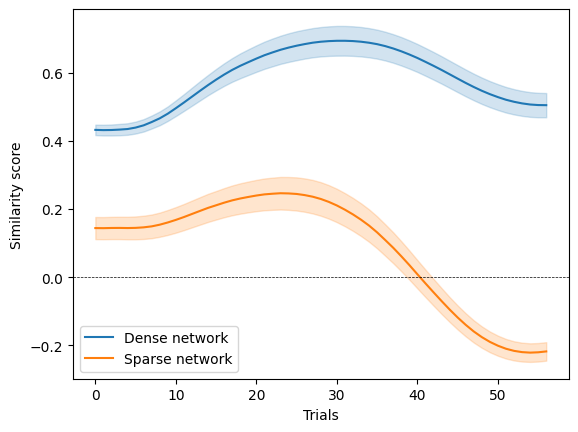

In [54]:
plot_multirun_sim_diff('../multirun/2026-06-22/02-07-41', title='')
plt.show()